# Three-dimensional real-data analysis for β0, β1, β2, Euler characteristic, and ECT

This notebook uses the real `sklearn` handwritten-digits dataset as a native 3D dataset. Each image is represented as a cloud in `(row, column, grayscale intensity)`, so the outcome lives in a 3D cubical grid.

The main exposure contrasts loop digits `{0, 6, 8, 9}` with non-loop digits `{1, 2, 3, 5, 7}`; digit `4` is omitted because its loop status is writer-dependent in small images. This is an observational real-data exercise, not a randomized causal experiment. Weak ignorability is therefore treated as a substantive assumption and investigated with proxy diagnostics. The analysis evaluates whether the proposed topological summaries detect differences in β0, β1, and especially β2 in an observed three-dimensional setting.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from scipy.special import expit
from skimage.measure import euler_number

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

BASE = Path.cwd()
PROJECT_DIR = BASE.parent if BASE.name == "notebooks" else BASE
FIG_DIR = PROJECT_DIR / "figures"
TAB_DIR = PROJECT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

SEED = 321
REF_Q = 0.40
QS = np.array([0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65])
SMOOTH_NATIVE = (0.5, 0.5, 0.8)
MIN_COMPONENT_SIZE = 1
B_BOOT = 30

## Shared 3D topology, ECT, and native intensity-volume helpers

The data are converted to a 3D image-intensity volume by accumulating mass at `(row, column, rounded intensity)` for each pixel in each image. Thresholds are quantiles of positive smoothed volume values, which is more stable than absolute thresholds for the small native grid.

In [ ]:
def clean_components(binary, min_component_size=MIN_COMPONENT_SIZE):
    b = np.asarray(binary, dtype=bool)
    if b.sum() == 0 or min_component_size <= 1:
        return b
    labels, _ = ndi.label(b, ndi.generate_binary_structure(3, 1))
    counts = np.bincount(labels.ravel())
    keep = np.flatnonzero(counts >= min_component_size)
    return np.isin(labels, keep) & (labels > 0)


def betti_numbers_3d(binary, min_component_size=MIN_COMPONENT_SIZE):
    b = clean_components(binary, min_component_size)
    if b.sum() == 0:
        return {"beta0": 0, "beta1": 0, "beta2": 0, "euler": 0, "voxels": 0}
    beta0 = int(ndi.label(b, ndi.generate_binary_structure(3, 1))[1])
    padded = np.pad(b, 1, constant_values=False)
    complement = ~padded
    labels_bg, n_bg = ndi.label(complement, ndi.generate_binary_structure(3, 3))
    border = np.zeros_like(complement, dtype=bool)
    border[0, :, :] = border[-1, :, :] = True
    border[:, 0, :] = border[:, -1, :] = True
    border[:, :, 0] = border[:, :, -1] = True
    outside = set(np.unique(labels_bg[border]))
    outside.discard(0)
    beta2 = int(len(set(range(1, n_bg + 1)) - outside))
    chi = int(euler_number(b, connectivity=1))
    beta1 = max(int(beta0 + beta2 - chi), 0)
    return {"beta0": beta0, "beta1": beta1, "beta2": beta2, "euler": chi, "voxels": int(b.sum())}


def native_intensity_volume(images, weights=None, smooth=SMOOTH_NATIVE, noise_sd=0.0, seed=SEED):
    images = np.asarray(images, dtype=float)
    rng = np.random.default_rng(seed)
    if weights is None:
        weights = np.ones(len(images), dtype=float)
    weights = np.asarray(weights, dtype=float)
    vol = np.zeros((8, 8, 17), dtype=float)
    rr = np.repeat(np.arange(8), 8)
    cc = np.tile(np.arange(8), 8)
    for i, img in enumerate(images):
        if noise_sd > 0:
            img = img + rng.normal(0, noise_sd, size=img.shape)
        vals = np.clip(np.rint(img), 0, 16).astype(int).ravel()
        np.add.at(vol, (rr, cc, vals), weights[i])
    return ndi.gaussian_filter(vol, sigma=smooth, mode="constant")


def threshold_quantile(vol, q=REF_Q):
    positive = vol[vol > 0]
    if len(positive) == 0:
        return np.inf
    return float(np.quantile(positive, q))


def summarize_volume_quantile(vol, qs=QS, min_component_size=MIN_COMPONENT_SIZE):
    rows = []
    for q in qs:
        thr = threshold_quantile(vol, q)
        row = betti_numbers_3d(vol >= thr, min_component_size)
        row["q"] = float(q)
        row["threshold"] = thr
        rows.append(row)
    return pd.DataFrame(rows)


def contrast_quantile(vol0, vol1, qs=QS, ref_q=REF_Q, min_component_size=MIN_COMPONENT_SIZE):
    s0 = summarize_volume_quantile(vol0, qs, min_component_size)
    s1 = summarize_volume_quantile(vol1, qs, min_component_size)
    rows = []
    for i, q in enumerate(qs):
        row = {"q": float(q)}
        for key in ["beta0", "beta1", "beta2", "euler"]:
            row[f"d_{key}"] = int(s1.loc[i, key] - s0.loc[i, key])
        rows.append(row)
    curve = pd.DataFrame(rows)
    ref = curve.iloc[(curve["q"] - ref_q).abs().argmin()].copy()
    return s0, s1, curve, ref


def make_directions():
    dirs = []
    for axis in np.eye(3):
        dirs.append(axis)
        dirs.append(-axis)
    for signs in [(-1, -1, -1), (-1, 1, 1), (1, -1, 1), (1, 1, -1), (1, 1, 1), (1, -1, -1), (-1, 1, -1), (-1, -1, 1)]:
        v = np.asarray(signs, dtype=float)
        dirs.append(v / np.linalg.norm(v))
    return np.vstack(dirs)


def finite_ect(binary, directions=None, n_steps=6):
    b = np.asarray(binary, dtype=bool)
    if directions is None:
        directions = make_directions()
    coords = np.indices(b.shape).reshape(3, -1).T.astype(float)
    coords = coords / np.maximum(np.asarray(b.shape) - 1, 1)
    flat_b = b.ravel()
    values = []
    for direction in directions:
        projection = coords @ direction
        for threshold in np.linspace(projection.min(), projection.max(), n_steps):
            sublevel = (flat_b & (projection <= threshold)).reshape(b.shape)
            values.append(int(euler_number(sublevel, connectivity=1)) if sublevel.any() else 0)
    return np.asarray(values, dtype=float)


def ect_contrast_quantile(vol0, vol1, q=REF_Q, directions=None, n_steps=6, min_component_size=MIN_COMPONENT_SIZE):
    b0 = clean_components(vol0 >= threshold_quantile(vol0, q), min_component_size)
    b1 = clean_components(vol1 >= threshold_quantile(vol1, q), min_component_size)
    return finite_ect(b1, directions, n_steps) - finite_ect(b0, directions, n_steps)

## Data construction, observed adjustment, and weak-ignorability diagnostics

The exposure is a digit morphology group. Because morphology is not assigned independently of the image, weak ignorability is not credible. We quantify this with covariate balance and exposure predictability from image features.

In [ ]:
def center_of_mass_features(images):
    images = np.asarray(images, dtype=float)
    rr, cc = np.meshgrid(np.arange(8), np.arange(8), indexing="ij")
    mass = images.sum(axis=(1, 2)) + 1e-9
    row_com = (images * rr[None, :, :]).sum(axis=(1, 2)) / mass
    col_com = (images * cc[None, :, :]).sum(axis=(1, 2)) / mass
    ink = images.sum(axis=(1, 2))
    high_intensity = (images >= 8).sum(axis=(1, 2))
    left = images[:, :, :4].sum(axis=(1, 2))
    right = images[:, :, 4:].sum(axis=(1, 2))
    top = images[:, :4, :].sum(axis=(1, 2))
    bottom = images[:, 4:, :].sum(axis=(1, 2))
    return pd.DataFrame({
        "ink": ink,
        "row_com": row_com,
        "col_com": col_com,
        "high_intensity_pixels": high_intensity,
        "left_minus_right": left - right,
        "top_minus_bottom": top - bottom,
    })


def weighted_mean(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        return float(np.mean(x))
    w = np.asarray(w, dtype=float)
    return float(np.sum(w * x) / np.sum(w))


def smd(x, T, w=None):
    x = np.asarray(x, dtype=float)
    T = np.asarray(T).astype(bool)
    if w is None:
        m1, m0 = np.mean(x[T]), np.mean(x[~T])
        v1, v0 = np.var(x[T]), np.var(x[~T])
    else:
        w = np.asarray(w, dtype=float)
        m1 = weighted_mean(x[T], w[T])
        m0 = weighted_mean(x[~T], w[~T])
        v1 = weighted_mean((x[T] - m1) ** 2, w[T])
        v0 = weighted_mean((x[~T] - m0) ** 2, w[~T])
    denom = np.sqrt((v1 + v0) / 2)
    return float((m1 - m0) / denom) if denom > 1e-12 else 0.0


def make_digits_data():
    digits = load_digits()
    images = digits.images.astype(float)
    labels = digits.target.astype(int)
    loop_digits = {0, 6, 8, 9}
    nonloop_digits = {1, 2, 3, 5, 7}
    keep = np.array([d in loop_digits or d in nonloop_digits for d in labels])
    images = images[keep]
    labels = labels[keep]
    T = np.array([0 if d in loop_digits else 1 for d in labels], dtype=int)
    features = center_of_mass_features(images)
    Xflat = images.reshape(len(images), -1)
    pcs = PCA(n_components=6, random_state=SEED).fit_transform(StandardScaler().fit_transform(Xflat))
    for j in range(pcs.shape[1]):
        features[f"pc{j+1}"] = pcs[:, j]
    features["digit"] = labels
    features["T"] = T
    return images, labels, features

images, labels, df = make_digits_data()
feature_cols = [c for c in df.columns if c not in ["digit", "T"]]
prop_model = LogisticRegression(max_iter=2000, C=0.05)
prop_model.fit(df[feature_cols], df["T"])
df["p_hat"] = np.clip(prop_model.predict_proba(df[feature_cols])[:, 1], 0.05, 0.95)
df["w_ipw"] = np.where(df["T"] == 1, 1 / df["p_hat"], 1 / (1 - df["p_hat"]))
df["w_overlap"] = np.where(df["T"] == 1, 1 - df["p_hat"], df["p_hat"])

rf = RandomForestClassifier(n_estimators=150, random_state=SEED, min_samples_leaf=3)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
auc = cross_val_score(rf, df[feature_cols], df["T"], cv=cv, scoring="roc_auc")

summary = pd.DataFrame({
    "quantity": ["n", "treated_nonloop_share", "n_loop_control", "n_nonloop_treated", "RF_CV_AUC_mean", "RF_CV_AUC_sd", "min_hat_p", "max_hat_p"],
    "value": [len(df), df["T"].mean(), int((df["T"] == 0).sum()), int((df["T"] == 1).sum()), auc.mean(), auc.std(), df.p_hat.min(), df.p_hat.max()]
})
print("Real digits design summary")
display(summary)

balance_rows = []
for cov in feature_cols:
    balance_rows.append({
        "covariate": cov,
        "raw": smd(df[cov], df["T"]),
        "IPW": smd(df[cov], df["T"], df["w_ipw"]),
        "overlap": smd(df[cov], df["T"], df["w_overlap"]),
    })
balance = pd.DataFrame(balance_rows)
print("Observed balance diagnostics. Strong raw imbalance and high exposure predictability make weak ignorability implausible in this real setting.")
display(balance)
balance.to_csv(TAB_DIR / "3d_real_digits_balance.csv", index=False)

conv_rows = []
T_bool = df["T"].to_numpy().astype(bool)
for cov in ["ink", "row_com", "col_com", "high_intensity_pixels", "left_minus_right", "top_minus_bottom"]:
    conv_rows.append({
        "summary": cov,
        "raw_diff_nonloop_minus_loop": df.loc[T_bool, cov].mean() - df.loc[~T_bool, cov].mean(),
        "IPW_diff": weighted_mean(df.loc[T_bool, cov], df.loc[T_bool, "w_ipw"]) - weighted_mean(df.loc[~T_bool, cov], df.loc[~T_bool, "w_ipw"]),
        "overlap_diff": weighted_mean(df.loc[T_bool, cov], df.loc[T_bool, "w_overlap"]) - weighted_mean(df.loc[~T_bool, cov], df.loc[~T_bool, "w_overlap"]),
    })
conventional = pd.DataFrame(conv_rows)
print("Conventional scalar contrasts")
display(conventional)
conventional.to_csv(TAB_DIR / "3d_real_digits_conventional_estimands.csv", index=False)

Real digits design summary


,quantity,value
0,n,1616.000000
1,treated_nonloop_share,0.558787
2,n_loop_control,713.000000
3,n_nonloop_treated,903.000000
4,RF_CV_AUC_mean,0.982091
5,RF_CV_AUC_sd,0.003987
6,min_hat_p,0.050000
7,max_hat_p,0.950000


Observed balance diagnostics. Strong raw imbalance and high exposure predictability make weak ignorability implausible in this real setting.


,covariate,raw,IPW,overlap
0,ink,-0.252680,-0.094251,-0.025920
1,row_com,-0.542330,-0.180785,-0.140859
2,col_com,0.071634,0.143174,-0.005817
3,high_intensity_pixels,-0.313720,-0.125940,-0.039856
4,left_minus_right,-0.268228,-0.195933,-0.021173
5,top_minus_bottom,0.388130,0.076422,0.014122
6,pc1,0.070084,-0.031815,-0.042631
7,pc2,-1.755774,-0.585577,-0.211993
8,pc3,0.048250,0.033948,0.017312
9,pc4,0.103352,0.131253,-0.044375


Conventional scalar contrasts


,summary,raw_diff_nonloop_minus_loop,IPW_diff,overlap_diff
0,ink,-8.852973,-3.384248,-0.939911
1,row_com,-0.211147,-0.069160,-0.050208
2,col_com,0.021119,0.042869,-0.001739
3,high_intensity_pixels,-0.854976,-0.342202,-0.109800
4,left_minus_right,-16.766277,-12.395996,-1.353084
5,top_minus_bottom,21.546634,4.095935,0.726169


## Main real-data topological estimands

Controls are loop digits and treated observations are non-loop digits. The topological contrast is therefore non-loop minus loop. Because the exposure is not randomized, the IPW and overlap-weighted versions are interpreted as adjusted descriptive estimands rather than as identified causal effects.

Reference-quantile real-data topological contrasts: non-loop minus loop


,method,q,d_beta0,d_beta1,d_beta2,d_euler
0,observed_raw,0.4,0.0,-1.0,1.0,2.0
1,observed_IPW,0.4,0.0,-2.0,2.0,4.0
2,observed_overlap,0.4,0.0,0.0,3.0,3.0


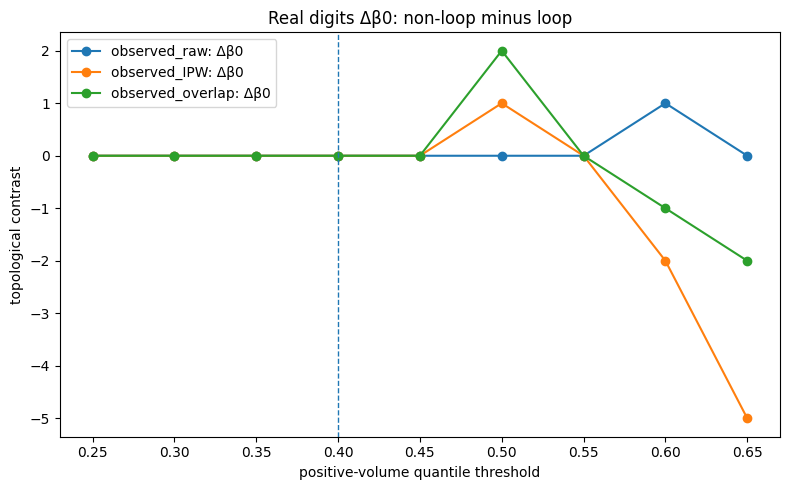

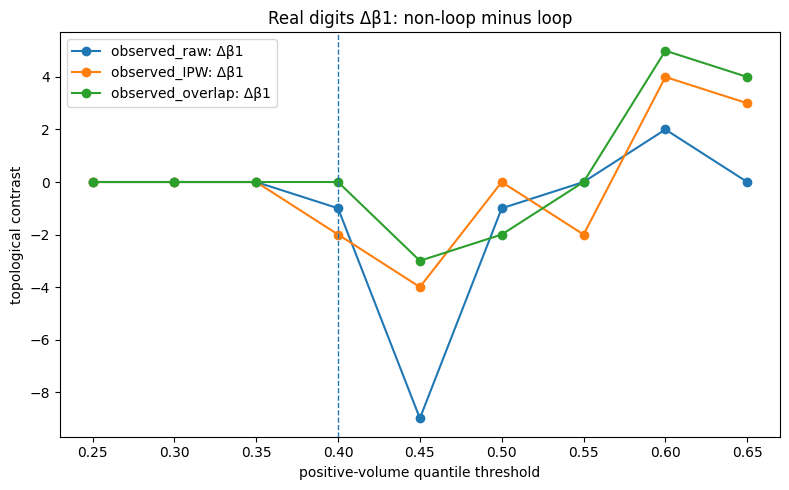

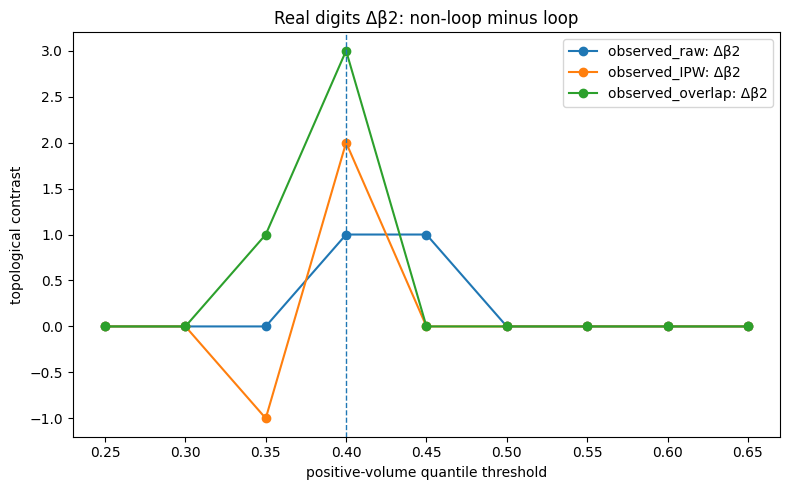

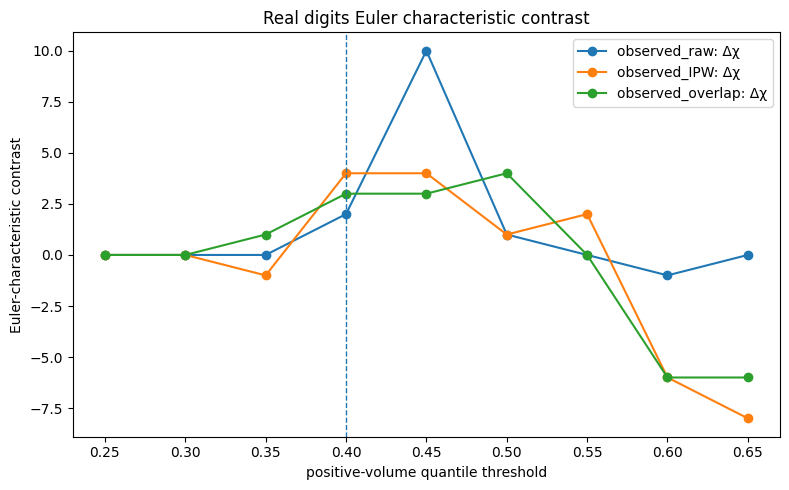

In [ ]:
def estimate_digits_methods(images, df, qs=QS, ref_q=REF_Q, noise_sd=0.0, seed=SEED):
    T = df["T"].to_numpy().astype(bool)
    specs = {
        "observed_raw": (None, None),
        "observed_IPW": (df["w_ipw"].to_numpy(), df["w_ipw"].to_numpy()),
        "observed_overlap": (df["w_overlap"].to_numpy(), df["w_overlap"].to_numpy()),
    }
    results = {}
    rows = []
    for name, (w0_all, w1_all) in specs.items():
        w0 = None if w0_all is None else w0_all[~T]
        w1 = None if w1_all is None else w1_all[T]
        vol0 = native_intensity_volume(images[~T], weights=w0, noise_sd=noise_sd, seed=seed)
        vol1 = native_intensity_volume(images[T], weights=w1, noise_sd=noise_sd, seed=seed + 7)
        s0, s1, curve, ref = contrast_quantile(vol0, vol1, qs, ref_q)
        results[name] = {"vol0": vol0, "vol1": vol1, "s0": s0, "s1": s1, "curve": curve, "ref": ref}
        rows.append({"method": name, **ref.to_dict()})
    return results, pd.DataFrame(rows)

main_results, ref_table = estimate_digits_methods(images, df)
print("Reference-quantile real-data topological contrasts: non-loop minus loop")
display(ref_table[["method", "q", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
ref_table.to_csv(TAB_DIR / "3d_real_digits_topological_reference.csv", index=False)

curve_long = []
for method, obj in main_results.items():
    c = obj["curve"].copy()
    c["method"] = method
    curve_long.append(c)
curve_long = pd.concat(curve_long, ignore_index=True)
curve_long.to_csv(TAB_DIR / "3d_real_digits_betti_curves.csv", index=False)

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["q"], obj["curve"]["d_beta0"], marker="o", label=f"{method}: Δβ0")
plt.axvline(REF_Q, linestyle="--", linewidth=1)
plt.xlabel("positive-volume quantile threshold")
plt.ylabel("topological contrast")
plt.title("Real digits Δβ0: non-loop minus loop")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_real_digits_delta_beta0.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["q"], obj["curve"]["d_beta1"], marker="o", label=f"{method}: Δβ1")
plt.axvline(REF_Q, linestyle="--", linewidth=1)
plt.xlabel("positive-volume quantile threshold")
plt.ylabel("topological contrast")
plt.title("Real digits Δβ1: non-loop minus loop")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_real_digits_delta_beta1.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["q"], obj["curve"]["d_beta2"], marker="o", label=f"{method}: Δβ2")
plt.axvline(REF_Q, linestyle="--", linewidth=1)
plt.xlabel("positive-volume quantile threshold")
plt.ylabel("topological contrast")
plt.title("Real digits Δβ2: non-loop minus loop")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_real_digits_delta_beta2.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, obj in main_results.items():
    plt.plot(obj["curve"]["q"], obj["curve"]["d_euler"], marker="o", label=f"{method}: Δχ")
plt.axvline(REF_Q, linestyle="--", linewidth=1)
plt.xlabel("positive-volume quantile threshold")
plt.ylabel("Euler-characteristic contrast")
plt.title("Real digits Euler characteristic contrast")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_real_digits_delta_euler.png", dpi=180)
plt.show()

## Observed-stratum topological stability diagnostics

The real dataset does not contain counterfactual outcomes or a known hidden confounder. The analysis therefore evaluates whether the finite topological signature is stable across observed style strata defined by total ink and the first image principal component. These comparisons are descriptive stability diagnostics and are not tests of conditional topological ignorability.

In [ ]:
def digit_signature(images_subset, label, weights=None, q=REF_Q):
    vol = native_intensity_volume(images_subset, weights=weights)
    sig = betti_numbers_3d(vol >= threshold_quantile(vol, q), MIN_COMPONENT_SIZE)
    sig["subset"] = label
    sig["q"] = q
    return sig

proxy_rows = []
T = df["T"].to_numpy().astype(bool)
for strat_name, strat_indicator in {
    "ink_low": df["ink"].to_numpy() <= df["ink"].median(),
    "ink_high": df["ink"].to_numpy() > df["ink"].median(),
    "pc1_low": df["pc1"].to_numpy() <= df["pc1"].median(),
    "pc1_high": df["pc1"].to_numpy() > df["pc1"].median(),
}.items():
    for group_name, group_mask in {"loop_control": ~T, "nonloop_treated": T}.items():
        m = strat_indicator & group_mask
        if m.sum() >= 30:
            proxy_rows.append(digit_signature(images[m], f"{group_name}_{strat_name}"))
proxy_table = pd.DataFrame(proxy_rows)[["subset", "q", "beta0", "beta1", "beta2", "euler", "voxels"]]
print("Observed-stratum finite topological signatures")
display(proxy_table)
proxy_table.to_csv(TAB_DIR / "3d_real_digits_proxy_topological_ignorability.csv", index=False)

Observed-stratum finite topological signatures


,subset,q,beta0,beta1,beta2,euler,voxels
0,loop_control_ink_low,0.4,1,1,2,2,653
1,nonloop_treated_ink_low,0.4,1,0,0,1,653
2,loop_control_ink_high,0.4,1,5,0,-4,653
3,nonloop_treated_ink_high,0.4,1,0,1,2,653
4,loop_control_pc1_low,0.4,1,1,0,0,653
5,nonloop_treated_pc1_low,0.4,1,0,1,2,653
6,loop_control_pc1_high,0.4,1,4,0,-3,653
7,nonloop_treated_pc1_high,0.4,1,0,1,2,653


## Euler Characteristic Transform summaries

The finite ECT is reported for each adjusted topological contrast. The raw ECT contrast is used as a reference because real potential-outcome distributions are not observed.

In [ ]:
directions = make_directions()
raw_ect = ect_contrast_quantile(main_results["observed_raw"]["vol0"], main_results["observed_raw"]["vol1"], directions=directions)
ect_rows = []
for method, obj in main_results.items():
    vec = ect_contrast_quantile(obj["vol0"], obj["vol1"], directions=directions)
    denom = np.linalg.norm(vec) * np.linalg.norm(raw_ect)
    cosine = float(np.dot(vec, raw_ect) / denom) if denom > 0 else np.nan
    ect_rows.append({
        "method": method,
        "ECT_L2_norm": float(np.linalg.norm(vec)),
        "ECT_mean": float(vec.mean()),
        "ECT_max_abs": float(np.max(np.abs(vec))),
        "cosine_to_raw": cosine,
        "L2_distance_to_raw": float(np.linalg.norm(vec - raw_ect)),
    })
ect_table = pd.DataFrame(ect_rows)
print("Finite ECT contrast summaries")
display(ect_table)
ect_table.to_csv(TAB_DIR / "3d_real_digits_ect_summary.csv", index=False)

Finite ECT contrast summaries


,method,ECT_L2_norm,ECT_mean,ECT_max_abs,cosine_to_raw,L2_distance_to_raw
0,observed_raw,15.066519,1.011905,4.0,1.000000,0.000000
1,observed_IPW,25.942244,1.964286,6.0,0.862203,15.033296
2,observed_overlap,19.287302,1.404762,5.0,0.801810,11.532563


## Robustness and sensitivity analyses

The analyses below vary threshold, additive grayscale noise, topological complexity of the exposure comparison, and an odds-tilt proxy. The complexity comparisons are all real-data contrasts among digit groups.

Bootstrap distribution for real digits IPW topological contrast


,d_beta0,d_beta1,d_beta2,d_euler
count,30.0,30.000000,30.000000,30.000000
mean,0.0,-2.033333,1.733333,3.766667
std,0.0,1.299425,0.520830,1.406471
min,0.0,-5.000000,1.000000,2.000000
25%,0.0,-3.000000,1.000000,3.000000
50%,0.0,-2.000000,2.000000,3.500000
75%,0.0,-1.000000,2.000000,5.000000
max,0.0,0.000000,3.000000,7.000000


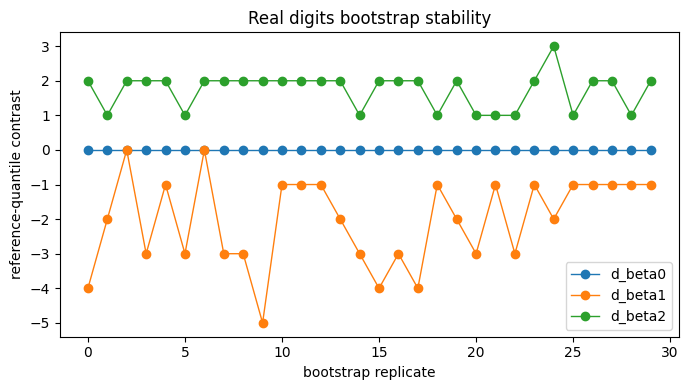

Grayscale-noise sensitivity


,noise_sd,method,d_beta0,d_beta1,d_beta2,d_euler
0,0.00,observed_raw,0.0,-1.0,1.0,2.0
1,0.00,observed_IPW,0.0,-2.0,2.0,4.0
2,0.00,observed_overlap,0.0,0.0,3.0,3.0
3,0.25,observed_raw,0.0,-3.0,1.0,4.0
4,0.25,observed_IPW,0.0,-1.0,2.0,3.0
5,0.25,observed_overlap,0.0,-1.0,2.0,3.0
6,0.50,observed_raw,0.0,-2.0,1.0,3.0
7,0.50,observed_IPW,0.0,-3.0,2.0,5.0
8,0.50,observed_overlap,0.0,0.0,1.0,1.0
9,0.75,observed_raw,0.0,-3.0,1.0,4.0


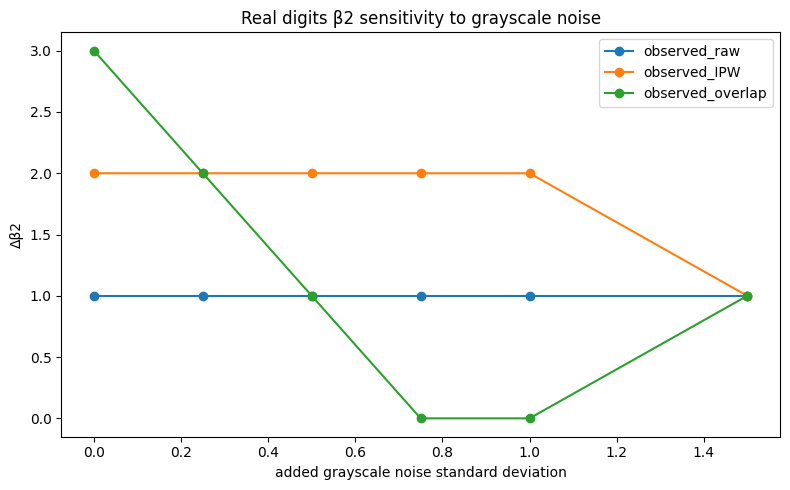

Real-data topological complexity comparisons


,comparison,control_digits,treated_digits,d_beta0,d_beta1,d_beta2,d_euler
0,nonloop_vs_loop_main,"[0, 6, 8, 9]","[1, 2, 3, 5, 7]",0.0,-1.0,1.0,2.0
1,eight_vs_nonloop,"[1, 2, 3, 5, 7]",[8],0.0,0.0,-1.0,-1.0
2,eight_vs_one_loop,"[0, 6, 9]",[8],0.0,-1.0,0.0,1.0
3,zero_vs_one,[1],[0],0.0,-1.0,1.0,2.0


Observed-style odds-tilt sensitivity


,gamma_ink_style_tilt,d_beta0,d_beta1,d_beta2,d_euler
0,-2.0,0.0,-1.0,-2.0,-1.0
1,-1.0,0.0,-1.0,1.0,2.0
2,-0.5,0.0,-1.0,2.0,3.0
3,0.0,0.0,-2.0,2.0,4.0
4,0.5,0.0,-3.0,2.0,5.0
5,1.0,0.0,2.0,0.0,-2.0
6,2.0,0.0,2.0,0.0,-2.0


In [ ]:
# Bootstrap stability of the IPW topological contrast.
rng = np.random.default_rng(SEED + 12)
boot_rows = []
idx_all = np.arange(len(df))
for b in range(B_BOOT):
    idx = rng.choice(idx_all, size=len(idx_all), replace=True)
    images_b = images[idx]
    df_b = df.iloc[idx].reset_index(drop=True)
    results_b, ref_b = estimate_digits_methods(images_b, df_b)
    row = ref_b[ref_b["method"] == "observed_IPW"].iloc[0].to_dict()
    row["bootstrap"] = b
    boot_rows.append(row)
boot = pd.DataFrame(boot_rows)
print("Bootstrap distribution for real digits IPW topological contrast")
display(boot[["d_beta0", "d_beta1", "d_beta2", "d_euler"]].describe())
boot.to_csv(TAB_DIR / "3d_real_digits_bootstrap_ipw.csv", index=False)

plt.figure(figsize=(7, 4))
for col in ["d_beta0", "d_beta1", "d_beta2"]:
    plt.plot(boot["bootstrap"], boot[col], marker="o", linewidth=1, label=col)
plt.xlabel("bootstrap replicate")
plt.ylabel("reference-quantile contrast")
plt.title("Real digits bootstrap stability")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_real_digits_bootstrap_beta_contrasts.png", dpi=180)
plt.show()

# Grayscale noise sensitivity.
noise_rows = []
for noise_sd in [0.0, 0.25, 0.50, 0.75, 1.00, 1.50]:
    results_n, ref_n = estimate_digits_methods(images, df, noise_sd=noise_sd, seed=SEED + int(100 * noise_sd))
    for _, row in ref_n.iterrows():
        noise_rows.append({"noise_sd": noise_sd, **row.to_dict()})
noise_table = pd.DataFrame(noise_rows)
print("Grayscale-noise sensitivity")
display(noise_table[["noise_sd", "method", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
noise_table.to_csv(TAB_DIR / "3d_real_digits_noise_sensitivity.csv", index=False)

plt.figure(figsize=(8, 5))
for method in noise_table["method"].unique():
    sub = noise_table[noise_table["method"] == method]
    plt.plot(sub["noise_sd"], sub["d_beta2"], marker="o", label=method)
plt.xlabel("added grayscale noise standard deviation")
plt.ylabel("Δβ2")
plt.title("Real digits β2 sensitivity to grayscale noise")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "3d_real_digits_noise_beta2.png", dpi=180)
plt.show()

# Topological complexity comparisons among real digit groups.
digits = load_digits()
all_images = digits.images.astype(float)
all_labels = digits.target.astype(int)
comparisons = {
    "nonloop_vs_loop_main": ({0, 6, 8, 9}, {1, 2, 3, 5, 7}),
    "eight_vs_nonloop": ({1, 2, 3, 5, 7}, {8}),
    "eight_vs_one_loop": ({0, 6, 9}, {8}),
    "zero_vs_one": ({1}, {0}),
}
complex_rows = []
for name, (control_digits, treated_digits) in comparisons.items():
    m0 = np.array([d in control_digits for d in all_labels])
    m1 = np.array([d in treated_digits for d in all_labels])
    vol0 = native_intensity_volume(all_images[m0])
    vol1 = native_intensity_volume(all_images[m1])
    ref = contrast_quantile(vol0, vol1)[3]
    complex_rows.append({"comparison": name, "control_digits": sorted(control_digits), "treated_digits": sorted(treated_digits), **ref.to_dict()})
complexity_table = pd.DataFrame(complex_rows)
print("Real-data topological complexity comparisons")
display(complexity_table[["comparison", "control_digits", "treated_digits", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
complexity_table.to_csv(TAB_DIR / "3d_real_digits_complexity_comparisons.csv", index=False)

# Odds-tilt sensitivity using an observed style proxy as the tilt direction.
tilt_rows = []
style = StandardScaler().fit_transform(df[["ink"]]).ravel()
for gamma in [-2, -1, -0.5, 0, 0.5, 1, 2]:
    w_tilt = df["w_ipw"].to_numpy() * np.exp(gamma * style)
    df_tilt = df.copy()
    df_tilt["w_ipw"] = w_tilt
    results_g, ref_g = estimate_digits_methods(images, df_tilt)
    row = ref_g[ref_g["method"] == "observed_IPW"].iloc[0].to_dict()
    tilt_rows.append({"gamma_ink_style_tilt": gamma, **row})
tilt_table = pd.DataFrame(tilt_rows)
print("Observed-style odds-tilt sensitivity")
display(tilt_table[["gamma_ink_style_tilt", "d_beta0", "d_beta1", "d_beta2", "d_euler"]])
tilt_table.to_csv(TAB_DIR / "3d_real_digits_odds_tilt.csv", index=False)

## Interpretation

The real-data exposure is not randomized, and weak ignorability is not established. The analysis therefore focuses on whether the adjusted 3D topological contrasts and ECT summaries remain stable across weighting, thresholding, noise, and observed style strata. A persistent nonzero Δβ2 indicates a detectable difference in void-like three-dimensional structure that is not captured by connected components (β0) or loops and tunnels (β1).